# Dataset & DataLoader - Breast Cancer Classification


---

## Table of Contents

1. [Introduction - Why Dataset & DataLoader?](#introduction)
2. [Setup & Load Data](#setup)
3. [Old Way (Without DataLoader)](#old-way)
4. [New Way (With DataLoader)](#new-way)
5. [Custom Dataset Class](#custom-dataset)
6. [DataLoader Parameters Explained](#parameters)
7. [Training with DataLoader](#training)
8. [Advanced Features](#advanced)
9. [Comparison & Best Practices](#comparison)

---

<a id='introduction'></a>
## 1. Introduction - Why Dataset & DataLoader?

### The Problem:

In our previous training pipeline, we loaded ALL data at once:

```python
#  Old way - everything in memory
X_train_tensor = torch.FloatTensor(X_train)  # All 455 samples loaded!
y_train_tensor = torch.FloatTensor(y_train)

# Then we process ALL at once
y_pred = model(X_train_tensor)  # 455 samples together!
```

**Problems:**
-  Small dataset (569 samples) = OK
-  Large dataset (1,000,000 samples) = OUT OF MEMORY!
-  Can't use mini-batch training (better optimization)
-  Can't easily shuffle data each epoch

### The Solution: Dataset & DataLoader

```python
#  New way - load in batches
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

for batch_features, batch_labels in train_loader:
    y_pred = model(batch_features)  # Only 32 samples at a time!
```

**Benefits:**
-  Memory efficient (process in batches)
-  Automatic shuffling each epoch
-  Parallel data loading (faster)
-  Better gradient estimates (mini-batch training)
-  Scales to ANY dataset size

---

<a id='setup'></a>
## 2. Setup & Load Data

In [25]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Load Breast Cancer Data

In [26]:
# Load dataset
df = pd.read_csv('/home/saif/Desktop/pytorch/brest_cancer_detection.csv')

print("📊 Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

📊 Dataset Overview:
Shape: (569, 33)

First few rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [27]:
# Data info
print("📋 Data Info:")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(df['diagnosis'].value_counts())
print(f"\nB (Benign): {(df['diagnosis'] == 'B').sum()} samples")
print(f"M (Malignant): {(df['diagnosis'] == 'M').sum()} samples")

📋 Data Info:
Missing values: 569

Target distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

B (Benign): 357 samples
M (Malignant): 212 samples


### Preprocess Data

In [28]:
# Clean data
df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')
df = df.dropna()

# Separate features and target
X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📦 Split:")
print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Encode labels (B->0, M->1)
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print(f"\n✅ Data preprocessed!")
print(f"Classes: {label_encoder.classes_} -> {label_encoder.transform(label_encoder.classes_)}")

Features shape: (569, 30)
Labels shape: (569,)

📦 Split:
Train: 455 samples
Test: 114 samples

✅ Data preprocessed!
Classes: ['B' 'M'] -> [0 1]


---

<a id='old-way'></a>
## 3. Old Way (Without DataLoader)

This is what we did in the previous training pipeline.

In [29]:
# Convert ALL data to tensors at once
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1).to(device)

print(" Old Way: Load ALL data at once")
print(f"\nX_train_tensor shape: {X_train_tensor.shape}")
print(f"Memory usage: {X_train_tensor.element_size() * X_train_tensor.nelement() / 1024:.2f} KB")
print(f"\nAll {X_train_tensor.shape[0]} samples in GPU memory!")

# Problems:
print("\nProblems:")
print("1. All data in memory (what if dataset is 1GB?)")
print("2. Can't easily shuffle")
print("3. No batching (process all 455 samples together)")
print("4. Hard to scale to large datasets")

 Old Way: Load ALL data at once

X_train_tensor shape: torch.Size([455, 30])
Memory usage: 53.32 KB

All 455 samples in GPU memory!

Problems:
1. All data in memory (what if dataset is 1GB?)
2. Can't easily shuffle
3. No batching (process all 455 samples together)
4. Hard to scale to large datasets


---

<a id='new-way'></a>
## 4. New Way (With DataLoader)

Let's use Dataset and DataLoader!

### 4.1 Using TensorDataset (Simplest Way)

In [30]:
# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

# Create TensorDataset
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

print("✅ New Way: Create Dataset")
print(f"\nTrain dataset length: {len(train_dataset)}")
print(f"Test dataset length: {len(test_dataset)}")

# Access individual samples
sample_features, sample_label = train_dataset[0]
print(f"\nFirst sample:")
print(f"Features shape: {sample_features.shape}")
print(f"Label: {sample_label.item()}")

✅ New Way: Create Dataset

Train dataset length: 455
Test dataset length: 114

First sample:
Features shape: torch.Size([30])
Label: 1.0


### 4.2 Create DataLoader

In [31]:
# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("✅ DataLoaders Created!")
print(f"\nTrain loader:")
print(f"  Total samples: {len(train_dataset)}")
print(f"  Batch size: {train_loader.batch_size}")
print(f"  Number of batches: {len(train_loader)}")
print(f"  Shuffle: {train_loader.dataset != train_loader.dataset}")

print(f"\nTest loader:")
print(f"  Total samples: {len(test_dataset)}")
print(f"  Batch size: {test_loader.batch_size}")
print(f"  Number of batches: {len(test_loader)}")

✅ DataLoaders Created!

Train loader:
  Total samples: 455
  Batch size: 32
  Number of batches: 15
  Shuffle: False

Test loader:
  Total samples: 114
  Batch size: 32
  Number of batches: 4


### 4.3 How DataLoader Works

In [32]:
# Get one batch
batch_features, batch_labels = next(iter(train_loader))

print(" One Batch from DataLoader:")
print(f"\nBatch features shape: {batch_features.shape}")
print(f"Batch labels shape: {batch_labels.shape}")
print(f"\nThis is {batch_features.shape[0]} samples out of {len(train_dataset)} total")

# Show what happens when iterating
print("\n🔄 Iterating through first 3 batches:")
for batch_idx, (features, labels) in enumerate(train_loader):
    print(f"Batch {batch_idx + 1}: Features {features.shape}, Labels {labels.shape}")
    if batch_idx == 2:
        break

print(f"\n... continues for total {len(train_loader)} batches")

 One Batch from DataLoader:

Batch features shape: torch.Size([32, 30])
Batch labels shape: torch.Size([32, 1])

This is 32 samples out of 455 total

🔄 Iterating through first 3 batches:
Batch 1: Features torch.Size([32, 30]), Labels torch.Size([32, 1])
Batch 2: Features torch.Size([32, 30]), Labels torch.Size([32, 1])
Batch 3: Features torch.Size([32, 30]), Labels torch.Size([32, 1])

... continues for total 15 batches


### 4.4 Memory Comparison

In [33]:
# Old way: ALL data in memory
old_way_memory = X_train_tensor.element_size() * X_train_tensor.nelement()

# New way: Only ONE batch in memory at a time
new_way_memory = batch_features.element_size() * batch_features.nelement()

print("💾 Memory Comparison:")
print(f"\nOld way (all data): {old_way_memory / 1024:.2f} KB")
print(f"New way (one batch): {new_way_memory / 1024:.2f} KB")
print(f"\nMemory saved: {(old_way_memory - new_way_memory) / 1024:.2f} KB")
print(f"Reduction: {(1 - new_way_memory/old_way_memory) * 100:.1f}%")

print("\n📈 For a 1,000,000 sample dataset:")
scale_factor = 1_000_000 / len(X_train)
print(f"Old way: {old_way_memory * scale_factor / (1024**2):.2f} MB")
print(f"New way: {new_way_memory / 1024:.2f} KB (same!)")

💾 Memory Comparison:

Old way (all data): 53.32 KB
New way (one batch): 3.75 KB

Memory saved: 49.57 KB
Reduction: 93.0%

📈 For a 1,000,000 sample dataset:
Old way: 114.44 MB
New way: 3.75 KB (same!)


---

<a id='custom-dataset'></a>
## 5. Custom Dataset Class

For more control, create a custom Dataset class.

In [34]:
class BreastCancerDataset(Dataset):
    """
    Custom Dataset for Breast Cancer data
    
    Must implement:
    1. __init__: Initialize data
    2. __len__: Return number of samples
    3. __getitem__: Return one sample
    """
    
    def __init__(self, features, labels, transform=None):
        """
        Args:
            features: numpy array of features (already scaled)
            labels: numpy array of labels (already encoded)
            transform: optional transform to apply
        """
        self.features = torch.FloatTensor(features)
        self.labels = torch.FloatTensor(labels).unsqueeze(1)
        self.transform = transform
    
    def __len__(self):
        """Return total number of samples"""
        return len(self.features)
    
    def __getitem__(self, idx):
        """
        Return one sample at given index
        
        Args:
            idx: index of sample to retrieve
        
        Returns:
            tuple: (features, label)
        """
        sample = self.features[idx]
        label = self.labels[idx]
        
        # Apply transformation if provided
        if self.transform:
            sample = self.transform(sample)
        
        return sample, label
    
    def get_num_features(self):
        """Helper method to get number of features"""
        return self.features.shape[1]

# Create custom datasets
custom_train_dataset = BreastCancerDataset(X_train, y_train)
custom_test_dataset = BreastCancerDataset(X_test, y_test)

print("✅ Custom Dataset Created!")
print(f"\nTrain dataset: {len(custom_train_dataset)} samples")
print(f"Test dataset: {len(custom_test_dataset)} samples")
print(f"Number of features: {custom_train_dataset.get_num_features()}")

# Test __getitem__
sample_x, sample_y = custom_train_dataset[0]
print(f"\nSample 0:")
print(f"  Features: {sample_x.shape}")
print(f"  Label: {sample_y.item()}")

✅ Custom Dataset Created!

Train dataset: 455 samples
Test dataset: 114 samples
Number of features: 30

Sample 0:
  Features: torch.Size([30])
  Label: 1.0


### Create DataLoaders from Custom Dataset

In [35]:
# Create DataLoaders
custom_train_loader = DataLoader(
    custom_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,  # Use 0 for Windows, 2-4 for Linux/Mac
    pin_memory=True if torch.cuda.is_available() else False
)

custom_test_loader = DataLoader(
    custom_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print("✅ Custom DataLoaders Created!")
print(f"\nTrain: {len(custom_train_loader)} batches of size {custom_train_loader.batch_size}")
print(f"Test: {len(custom_test_loader)} batches of size {custom_test_loader.batch_size}")

✅ Custom DataLoaders Created!

Train: 15 batches of size 32
Test: 4 batches of size 32


---

<a id='parameters'></a>
## 6. DataLoader Parameters Explained

### 6.1 batch_size - How many samples per batch?

In [36]:
# Try different batch sizes
batch_sizes = [16, 32, 64, 128]

print("📦 Different Batch Sizes:\n")
for bs in batch_sizes:
    loader = DataLoader(custom_train_dataset, batch_size=bs)
    print(f"Batch size {bs:3d}: {len(loader):2d} batches")

print("\n💡 Choosing batch size:")
print("  • Too small (8, 16): Slow training, noisy gradients")
print("  • Too large (256, 512): May not fit in GPU memory")
print("  • Sweet spot: 32, 64, 128")

📦 Different Batch Sizes:

Batch size  16: 29 batches
Batch size  32: 15 batches
Batch size  64:  8 batches
Batch size 128:  4 batches

💡 Choosing batch size:
  • Too small (8, 16): Slow training, noisy gradients
  • Too large (256, 512): May not fit in GPU memory
  • Sweet spot: 32, 64, 128


### 6.2 shuffle - Randomize order?

In [37]:
# Without shuffle
loader_no_shuffle = DataLoader(custom_train_dataset, batch_size=32, shuffle=False)

# With shuffle
loader_with_shuffle = DataLoader(custom_train_dataset, batch_size=32, shuffle=True)

# Get first batch from each
_, labels_no_shuffle = next(iter(loader_no_shuffle))
_, labels_with_shuffle = next(iter(loader_with_shuffle))

print("🔄 Shuffle Effect:\n")
print(f"Without shuffle (first 10 labels): {labels_no_shuffle[:10].squeeze().tolist()}")
print(f"With shuffle (first 10 labels): {labels_with_shuffle[:10].squeeze().tolist()}")

print("\n💡 When to use:")
print("  ✅ shuffle=True: Training (randomize each epoch)")
print("  ❌ shuffle=False: Validation/Test (consistent order)")

🔄 Shuffle Effect:

Without shuffle (first 10 labels): [1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0]
With shuffle (first 10 labels): [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]

💡 When to use:
  ✅ shuffle=True: Training (randomize each epoch)
  ❌ shuffle=False: Validation/Test (consistent order)


### 6.3 drop_last - Drop incomplete last batch?

In [38]:
# With drop_last=False (default)
loader_keep = DataLoader(custom_train_dataset, batch_size=32, drop_last=False)

# With drop_last=True
loader_drop = DataLoader(custom_train_dataset, batch_size=32, drop_last=True)

print(f"📊 Dataset size: {len(custom_train_dataset)} samples\n")
print(f"drop_last=False: {len(loader_keep)} batches")
print(f"drop_last=True: {len(loader_drop)} batches")

# Check last batch size
for batch_idx, (features, _) in enumerate(loader_keep):
    if batch_idx == len(loader_keep) - 1:
        print(f"\nLast batch size (keep): {features.shape[0]}")

for batch_idx, (features, _) in enumerate(loader_drop):
    if batch_idx == len(loader_drop) - 1:
        print(f"Last batch size (drop): {features.shape[0]}")

print("\n💡 When to use:")
print("  • drop_last=True: When batch size must be exact (some models require this)")
print("  • drop_last=False: Use all data (default, usually best)")

📊 Dataset size: 455 samples

drop_last=False: 15 batches
drop_last=True: 14 batches

Last batch size (keep): 7
Last batch size (drop): 32

💡 When to use:
  • drop_last=True: When batch size must be exact (some models require this)
  • drop_last=False: Use all data (default, usually best)


### 6.4 Complete Configuration

In [39]:
# Optimal configuration for training
train_loader_optimal = DataLoader(
    custom_train_dataset,
    batch_size=32,           # Good default
    shuffle=True,            # Randomize for training
    num_workers=0,           # 0 for Windows, 2-4 for Linux
    pin_memory=True if torch.cuda.is_available() else False,  # Faster GPU transfer
    drop_last=False          # Use all data
)

# Optimal configuration for testing
test_loader_optimal = DataLoader(
    custom_test_dataset,
    batch_size=64,           # Can be larger (no backprop)
    shuffle=False,           # Don't shuffle test data
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=False
)

print("✅ Optimal DataLoaders Configured!")

✅ Optimal DataLoaders Configured!


---

<a id='training'></a>
## 7. Training with DataLoader

Let's train our breast cancer classifier using DataLoader!

### 7.1 Define Model (Same as Before)

In [40]:
class BinaryClassifier(nn.Module):
    def __init__(self, input_size):
        super(BinaryClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# Initialize
input_size = custom_train_dataset.get_num_features()
model = BinaryClassifier(input_size).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model: {sum(p.numel() for p in model.parameters())} parameters")

Model: 4097 parameters


### 7.2 Training Loop with DataLoader

In [41]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch using DataLoader"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Iterate through batches
    for batch_features, batch_labels in train_loader:
        # Move to device
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        
        # Forward pass
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item()
        predictions = (outputs >= 0.5).float()
        correct += (predictions == batch_labels).sum().item()
        total += batch_labels.size(0)
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, test_loader, criterion, device):
    """Evaluate on test set using DataLoader"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)
            
            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)
            
            running_loss += loss.item()
            predictions = (outputs >= 0.5).float()
            correct += (predictions == batch_labels).sum().item()
            total += batch_labels.size(0)
    
    epoch_loss = running_loss / len(test_loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

print("✅ Training functions defined")

✅ Training functions defined


### 7.3 Train the Model

In [42]:
# Training
num_epochs = 50
train_losses, train_accs = [], []
test_losses, test_accs = [], []

print("🚀 Training with DataLoader...\n")
print("Epoch | Train Loss | Train Acc | Test Loss | Test Acc")
print("-" * 60)

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader_optimal, criterion, optimizer, device
    )
    
    # Evaluate
    test_loss, test_acc = evaluate(
        model, test_loader_optimal, criterion, device
    )
    
    # Store
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    # Print
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"{epoch+1:5d} | {train_loss:10.4f} | {train_acc:9.4f} | "
              f"{test_loss:9.4f} | {test_acc:8.4f}")

print("\n✅ Training completed!")
print(f"\nFinal Results:")
print(f"  Train Accuracy: {train_accs[-1]*100:.2f}%")
print(f"  Test Accuracy: {test_accs[-1]*100:.2f}%")

🚀 Training with DataLoader...

Epoch | Train Loss | Train Acc | Test Loss | Test Acc
------------------------------------------------------------
    1 |     0.6213 |    0.8549 |    0.5494 |   0.9035
   10 |     0.0606 |    0.9802 |    0.0660 |   0.9825
   20 |     0.0321 |    0.9912 |    0.0636 |   0.9825
   30 |     0.0177 |    0.9934 |    0.0690 |   0.9825
   40 |     0.0098 |    1.0000 |    0.0853 |   0.9825
   50 |     0.0054 |    1.0000 |    0.1055 |   0.9825

✅ Training completed!

Final Results:
  Train Accuracy: 100.00%
  Test Accuracy: 98.25%


### 7.4 Visualize Training

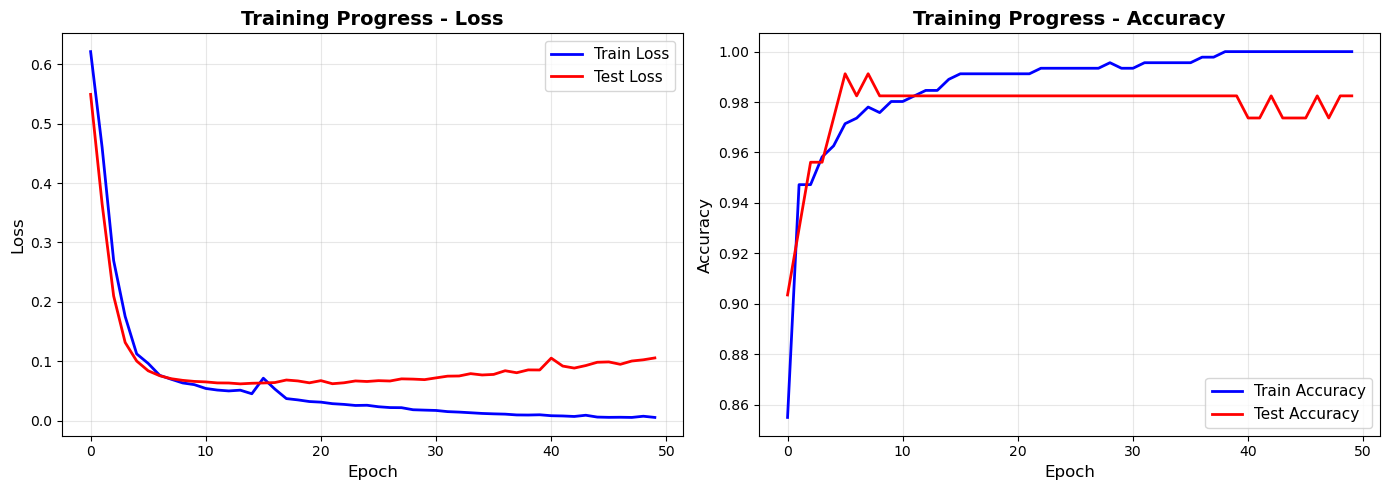

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', color='blue', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', color='red', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Progress - Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(train_accs, label='Train Accuracy', color='blue', linewidth=2)
axes[1].plot(test_accs, label='Test Accuracy', color='red', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training Progress - Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

<a id='advanced'></a>
## 8. Advanced Features

### 8.1 Train-Validation Split with random_split

In [44]:
# Split train into train+validation (80-20)
train_size = int(0.8 * len(custom_train_dataset))
val_size = len(custom_train_dataset) - train_size

train_subset, val_subset = random_split(
    custom_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create loaders
train_loader_split = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader_split = DataLoader(val_subset, batch_size=32, shuffle=False)

print("📊 Dataset Split:")
print(f"  Original train: {len(custom_train_dataset)} samples")
print(f"  New train: {len(train_subset)} samples ({train_size/len(custom_train_dataset)*100:.0f}%)")
print(f"  Validation: {len(val_subset)} samples ({val_size/len(custom_train_dataset)*100:.0f}%)")
print(f"  Test: {len(custom_test_dataset)} samples")

print("\n✅ Now you can train on train_loader_split and validate on val_loader_split!")

📊 Dataset Split:
  Original train: 455 samples
  New train: 364 samples (80%)
  Validation: 91 samples (20%)
  Test: 114 samples

✅ Now you can train on train_loader_split and validate on val_loader_split!


### 8.2 Handling Imbalanced Data

In [45]:
from torch.utils.data import WeightedRandomSampler

# Check class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("📊 Class Distribution:")
for cls, count in zip(unique, counts):
    class_name = 'Benign' if cls == 0 else 'Malignant'
    print(f"  Class {cls} ({class_name}): {count} samples ({count/len(y_train)*100:.1f}%)")

# Calculate sample weights for balanced sampling
class_counts = np.bincount(y_train)
class_weights = 1. / class_counts
sample_weights = class_weights[y_train]

# Create sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoader with sampler
balanced_loader = DataLoader(
    custom_train_dataset,
    batch_size=32,
    sampler=sampler  # Don't use shuffle with sampler!
)

# Check balanced batch
_, labels = next(iter(balanced_loader))
unique, counts = torch.unique(labels, return_counts=True)
print("\n📊 Balanced Batch Distribution:")
for cls, count in zip(unique, counts):
    class_name = 'Benign' if cls == 0 else 'Malignant'
    print(f"  Class {int(cls)} ({class_name}): {count.item()} samples ({count.item()/len(labels)*100:.1f}%)")

print("\n✅ Imbalanced data handled with WeightedRandomSampler!")

📊 Class Distribution:
  Class 0 (Benign): 285 samples (62.6%)
  Class 1 (Malignant): 170 samples (37.4%)

📊 Balanced Batch Distribution:
  Class 0 (Benign): 17 samples (53.1%)
  Class 1 (Malignant): 15 samples (46.9%)

✅ Imbalanced data handled with WeightedRandomSampler!


### 8.3 Batch Statistics

In [46]:
# Analyze batches
batch_sizes = []
label_distributions = []

for features, labels in train_loader_optimal:
    batch_sizes.append(features.shape[0])
    label_distributions.append((labels == 1).sum().item() / len(labels))

print("📊 Batch Statistics:")
print(f"\nBatch size:")
print(f"  Min: {min(batch_sizes)}")
print(f"  Max: {max(batch_sizes)}")
print(f"  Mean: {np.mean(batch_sizes):.1f}")

print(f"\nLabel distribution (% Malignant):")
print(f"  Min: {min(label_distributions)*100:.1f}%")
print(f"  Max: {max(label_distributions)*100:.1f}%")
print(f"  Mean: {np.mean(label_distributions)*100:.1f}%")
print(f"  Expected: {(y_train == 1).sum() / len(y_train)*100:.1f}%")

📊 Batch Statistics:

Batch size:
  Min: 7
  Max: 32
  Mean: 30.3

Label distribution (% Malignant):
  Min: 18.8%
  Max: 46.9%
  Mean: 36.9%
  Expected: 37.4%


---

<a id='comparison'></a>
## 9. Comparison & Best Practices

### 9.1 Side-by-Side Comparison

In [47]:
print("📊 Old Way vs New Way\n")
print("="*70)
print(f"{'Feature':<30} {'Old Way':<20} {'New Way (DataLoader)':<20}")
print("="*70)
print(f"{'Memory usage':<30} {'ALL data in RAM':<20} {'Only 1 batch':<20}")
print(f"{'Shuffling':<30} {'Manual':<20} {'Automatic':<20}")
print(f"{'Batching':<30} {'Manual':<20} {'Automatic':<20}")
print(f"{'Parallel loading':<30} {'No':<20} {'Yes (num_workers)':<20}")
print(f"{'GPU transfer':<30} {'Manual':<20} {'Auto (pin_memory)':<20}")
print(f"{'Scales to large data':<30} {'❌ No':<20} {'✅ Yes':<20}")
print(f"{'Code complexity':<30} {'Simple but limited':<20} {'Clean & powerful':<20}")
print("="*70)

📊 Old Way vs New Way

Feature                        Old Way              New Way (DataLoader)
Memory usage                   ALL data in RAM      Only 1 batch        
Shuffling                      Manual               Automatic           
Batching                       Manual               Automatic           
Parallel loading               No                   Yes (num_workers)   
GPU transfer                   Manual               Auto (pin_memory)   
Scales to large data           ❌ No                 ✅ Yes               
Code complexity                Simple but limited   Clean & powerful    


### 9.2 Best Practices Summary

#### ✅ DO:

```python
# 1. Always use DataLoader (even for small datasets)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 2. Shuffle training data
train_loader = DataLoader(..., shuffle=True)

# 3. Don't shuffle test data
test_loader = DataLoader(..., shuffle=False)

# 4. Use pin_memory for GPU
train_loader = DataLoader(..., pin_memory=True if torch.cuda.is_available() else False)

# 5. Move data to device in training loop
for features, labels in train_loader:
    features = features.to(device)
    labels = labels.to(device)
    # train...

# 6. Use appropriate batch size (32, 64, 128)
train_loader = DataLoader(..., batch_size=32)
```

#### ❌ DON'T:

```python
# 1. Don't load all data at once
# all_data = torch.FloatTensor(X)  # Bad for large datasets

# 2. Don't shuffle test data
# test_loader = DataLoader(..., shuffle=True)  # Wrong!

# 3. Don't forget to move data to device
# output = model(features)  # If features still on CPU and model on GPU - ERROR!

# 4. Don't use huge batch sizes
# train_loader = DataLoader(..., batch_size=1024)  # May not fit in memory
```

### 9.3 Quick Reference

```python
# Standard workflow

# 1. Create Dataset
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

# 2. Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,  # 0 for Windows
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

# 3. Training loop
for epoch in range(num_epochs):
    for features, labels in train_loader:
        features = features.to(device)
        labels = labels.to(device)
        
        # Forward
        outputs = model(features)
        loss = criterion(outputs, labels)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```